# Assignment 1B: Domain LLM Adaptation and Production Optimization

**Domain:** Medical and Clinical Literature (Variant 4: Clinical Protocol Lookup Assistant). **Model:** `mistralai/Mistral-7B-v0.1`
(A100 choice from the brief, base model with its own tokenizer throughout).
**Where it ran:** BITS Prayogshala / Kubeflow, NVIDIA A100-SXM4-80GB, the instructor's pinned environment (torch 2.5.1, transformers 4.46.3,
peft 0.13.2, bitsandbytes 0.44.1). Repository: https://github.com/bheemreddy1729/fine-tuning-Mistral-7B

| Section | Content | Marks |
|---|---|---|
| Part A, Step 1 | Corpus collection and cleaning (extraction, language, length, deduplication, statistics) | 1 |
| Part A, Step 2 | bfloat16 baseline: architecture report and 3 prompts | 1 |
| Part B | Instruction dataset, QLoRA Adapter B, baseline vs adapter *(added in the next build step)* | 5 |
| Part C | Decoding strategies, speculative decoding, 4-bit and cost *(added in the next build step)* | 8 |

All code is in the cells below and is the code that produced the outputs. Lab-run outputs are written to `reports_lab/`, and each
result is checked against the earlier run stored in `reports/`.

## 0. Execution environment (proof that the work ran on the BITS lab)

In [1]:
import os, sys, json, re, csv, time, hashlib, platform, subprocess
from importlib.metadata import version
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
from collections import Counter
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "sources.json").is_file():
    ROOT = ROOT.parent
os.chdir(ROOT)
REPORTS_LAB = ROOT / "reports_lab"          # new outputs; the earlier run in reports/ is kept untouched for comparison
REPORTS_LAB.mkdir(exist_ok=True)

try:
    import pymupdf, langdetect
except ImportError:                          # only extras the lab image lacks; never touches the pinned torch/transformers stack
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pymupdf", "langdetect"], check=True)
    import pymupdf, langdetect
import pandas as pd
import matplotlib.pyplot as plt
import torch, transformers

print("python      :", platform.python_version(), "|", sys.executable)
print("torch       :", torch.__version__, "| CUDA", torch.version.cuda, "| available:", torch.cuda.is_available())
print("transformers:", transformers.__version__, "| pymupdf", version("pymupdf"), "| langdetect", version("langdetect"), "| pandas", pd.__version__)
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print("GPU         :", p.name, f"{p.total_memory/1e9:.1f} GB")
print("repo root   :", ROOT)

python      : 3.11.11 | /home/jovyan/data/venv/bin/python
torch       : 2.5.1+cu124 | CUDA 12.4 | available: True
transformers: 4.46.3 | pymupdf 1.28.2 | langdetect 1.0.9 | pandas 2.2.3


GPU         : NVIDIA A100-SXM4-80GB 85.0 GB
repo root   : /home/jovyan/data/fine-tuning-Mistral-7B


**Kubeflow notebook server running (1 GPU, 4 CPU, 15.5 Gi)**

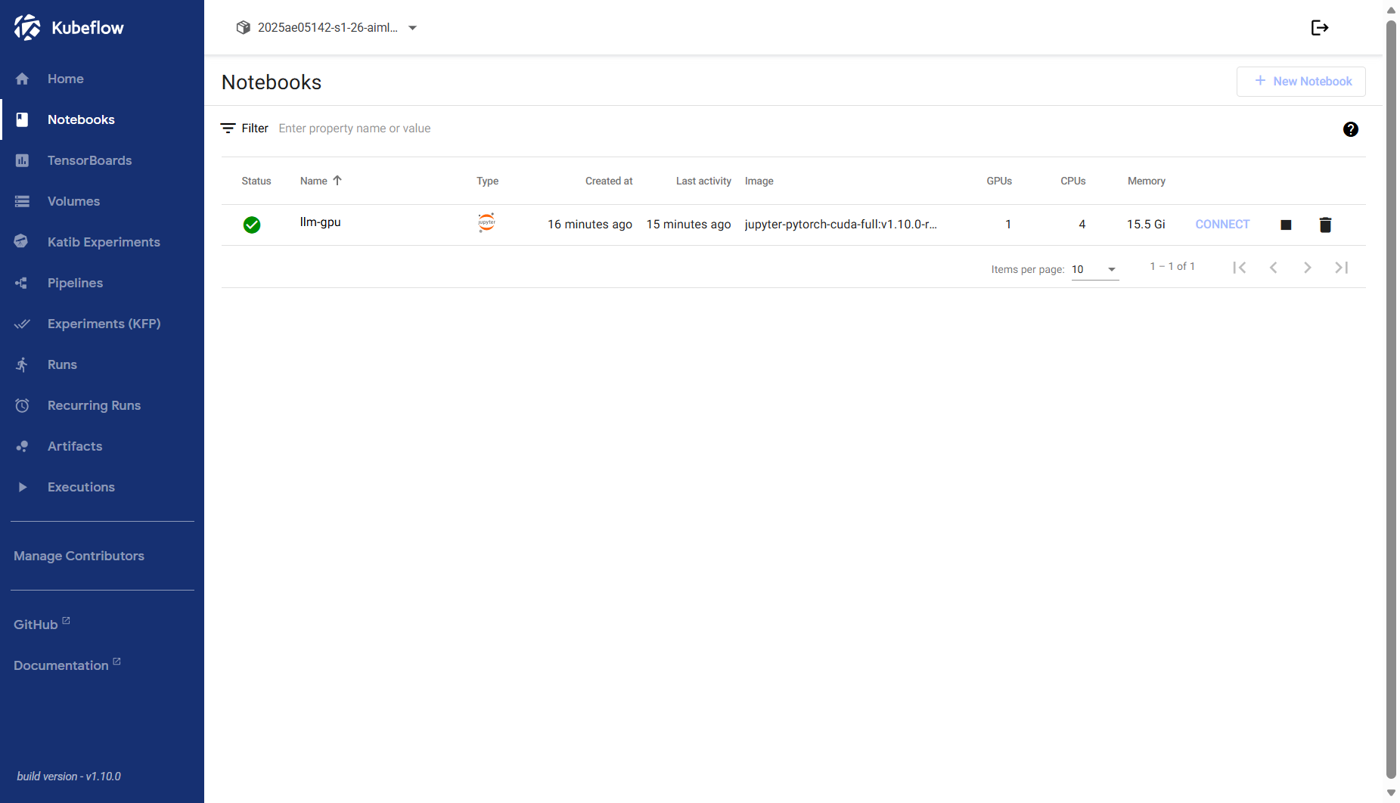

**Pod memory, 15 Gi data volume and GPU memory**

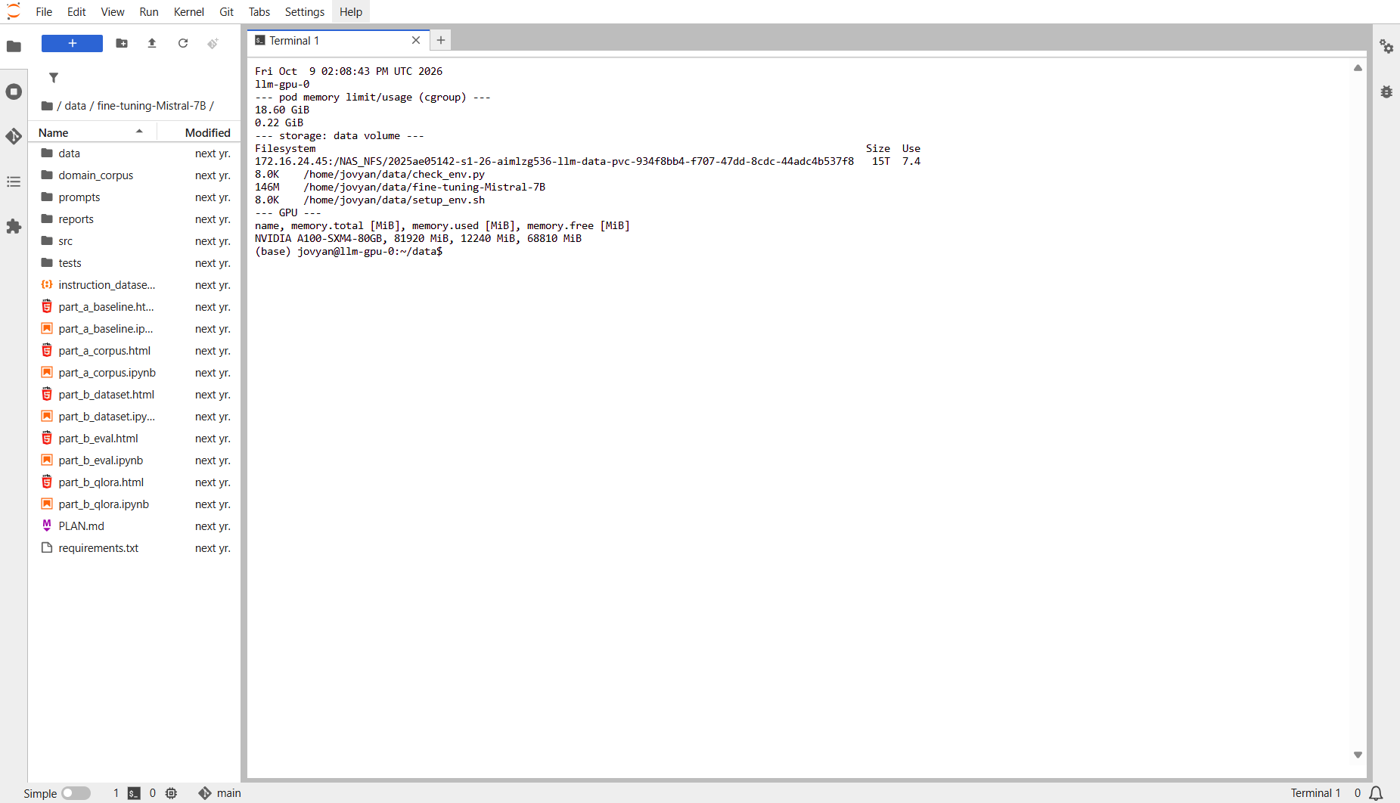

**nvidia-smi: NVIDIA A100-SXM4-80GB**

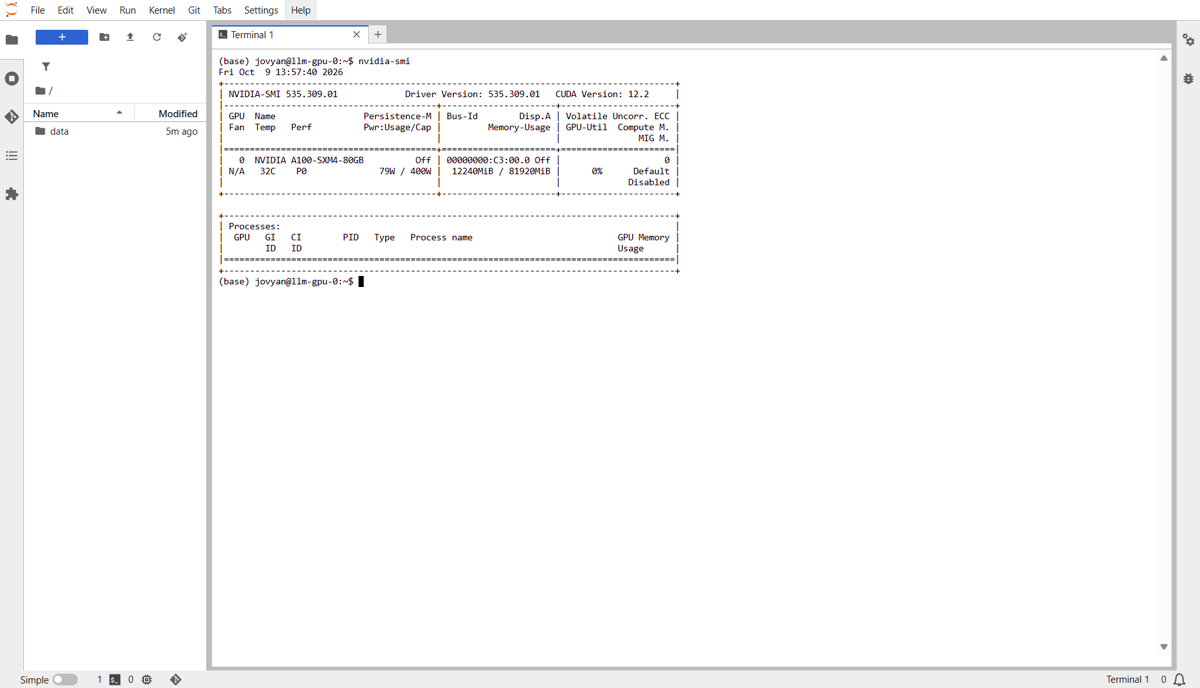

**Instructor check_env.py: all checks passed**

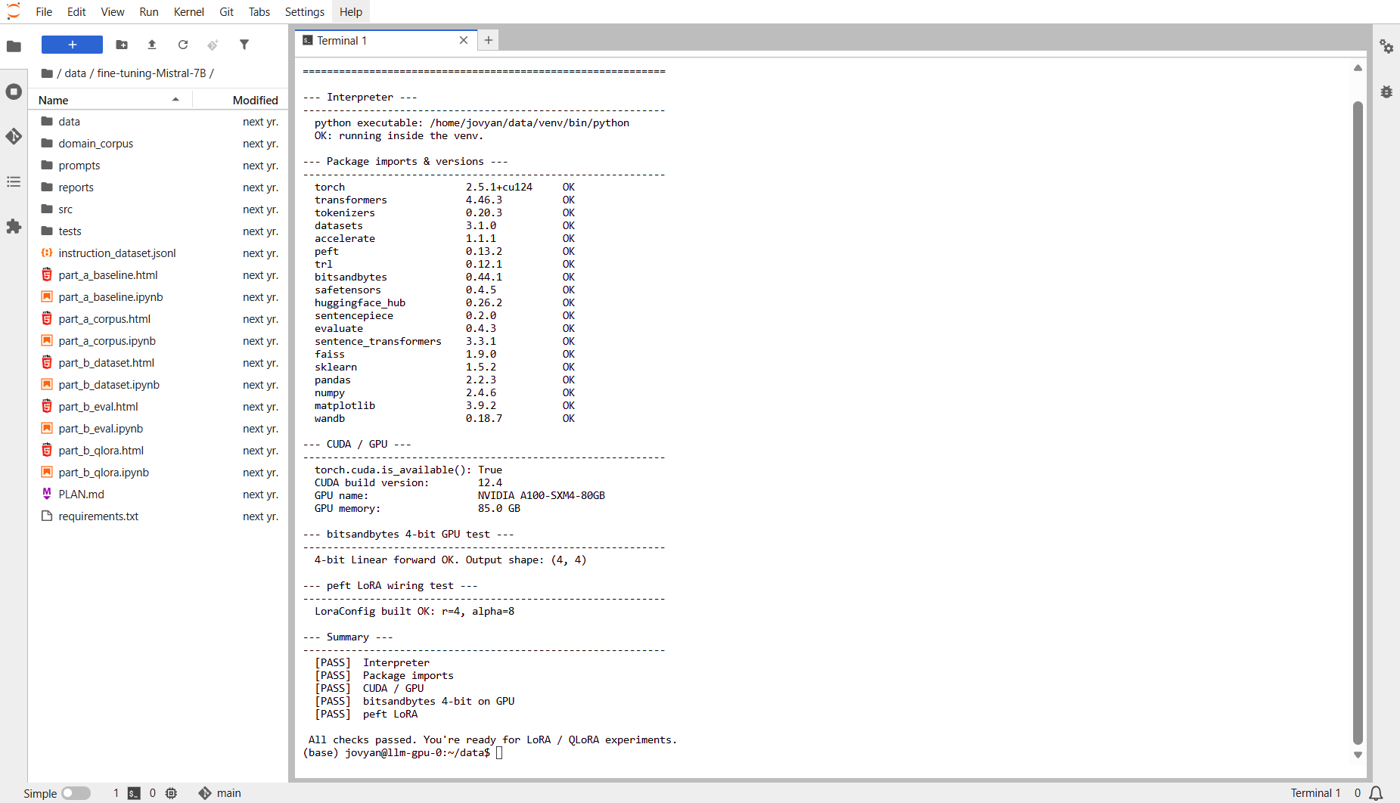

In [2]:
from IPython.display import Image, display, Markdown
EVIDENCE = [
    ("Kubeflow notebook server running (1 GPU, 4 CPU, 15.5 Gi)", "01_kubeflow_notebook_running.png"),
    ("Pod memory, 15 Gi data volume and GPU memory", "04_pod_terminal_memory_storage_gpu.png"),
    ("nvidia-smi: NVIDIA A100-SXM4-80GB", "05_pod_terminal_nvidia-smi_A100.png"),
    ("Instructor check_env.py: all checks passed", "07_check_env_all_checks_passed.png"),
]
for caption, name in EVIDENCE:
    path = ROOT / "lab_evidence" / name
    if path.is_file():
        display(Markdown(f"**{caption}**"))
        display(Image(filename=str(path), width=900))

## Part A, Step 1: Domain data collection and cleaning

**Aim.** Build a clean English clinical corpus from PDFs, one `.txt` file per document in `domain_corpus/`, with statistics before and after each
cleaning step. The same corpus feeds Part B (instruction dataset) and Part C (benchmark prompts).

**Sources.** Seven public clinical guidance PDFs (WHO malaria, CDC STI, NICE sepsis NG253, NICE hypertension NG136, ICMR antimicrobial,
ICMR Standard Treatment Workflows vol 1 and 3). The brief asks for at least 5 PDFs and the course note asks for at least 300 pages in total.
`data/sources.json` records title, URL, licence, byte size and page count for each file. WHO text is CC BY-NC-SA 3.0 IGO and is attributed there.
Raw PDFs are committed in `data/raw_pdfs/`, so the run is reproducible without network access (a missing or mismatched PDF is downloaded).

In [3]:
from urllib.request import Request, urlopen

SOURCES = json.loads((ROOT / "data" / "sources.json").read_text(encoding="utf-8"))["documents"]

def pdf_ok(path: Path, src: dict) -> bool:
    if not path.is_file() or path.stat().st_size != int(src["bytes"]) or path.read_bytes()[:5] != b"%PDF-":
        return False
    with pymupdf.open(path) as d:
        return d.page_count == int(src["page_count"])

for src in SOURCES:
    path = ROOT / src["file"]
    if not pdf_ok(path, src):                # download only a missing or mismatched file
        path.parent.mkdir(parents=True, exist_ok=True)
        req = Request(src["url"], headers={"User-Agent": "BITS-Mistral-corpus/1.0 (educational assignment)"})
        path.write_bytes(urlopen(req, timeout=180).read())
    assert pdf_ok(path, src), f"{src['id']} does not match sources.json"

pd.DataFrame([{"id": s["id"], "publisher": s["source"], "pages": s["page_count"], "MB": round(s["bytes"] / 1e6, 1),
               "licence": s["license"].split(".")[0]} for s in SOURCES])

,id,publisher,pages,MB,licence
0,who_malaria_2024-11-30,WHO,463,5.4,CC BY-NC-SA 3
1,cdc_sti_2021,CDC,192,4.8,US government work
2,nice_ng253_sepsis,NICE,97,0.4,NICE copyright
3,nice_ng136_hypertension,NICE,52,0.3,NICE copyright
4,icmr_antimicrobial_2019,ICMR,206,4.9,All rights reserved
5,icmr_stw_vol1_2019,ICMR,75,16.2,Indian Council of Medical Research and Departm...
6,icmr_stw_vol3_2022,ICMR,80,24.7,Indian Council of Medical Research and Departm...


### 1a. Page-by-page extraction

Each PDF is read with PyMuPDF, one page at a time. Runs of spaces are collapsed because PyMuPDF versions differ in how many spaces they emit, which
otherwise changes character counts between machines. Pages are stored with `<<<PAGE n>>>` markers so later filters can drop single pages and the
page number is never lost. A page with fewer than 30 letters (blank, image-only, a cover) is recorded as *non-content*.

In [4]:
MIN_LETTERS, MIN_PAGES, MIN_WORDS = 30, 3, 1000
SHINGLE, JACCARD_T = 5, 0.90

letters = lambda t: sum(c.isalpha() for c in t)
words   = lambda t: len(t.split())

def extract(src):
    with pymupdf.open(ROOT / src["file"]) as d:
        return [re.sub(r" {2,}", " ", pg.get_text("text")) for pg in d]

raw = {s["id"]: dict(enumerate(extract(s), start=1)) for s in SOURCES}                          # as extracted
corpus = {i: {n: t.rstrip() for n, t in p.items()} for i, p in raw.items()}                    # trailing whitespace trimmed
for s in SOURCES:
    assert len(corpus[s["id"]]) == s["page_count"]

def stats(stage, c, removed_docs=0, removed_pages=0):
    return {"stage": stage, "pdf_count": sum(1 for p in c.values() if p), "page_count": sum(len(p) for p in c.values()),
            "word_count": sum(words(t) for p in c.values() for t in p.values()),
            "character_count": sum(len(t) for p in c.values() for t in p.values()),
            "documents_removed": removed_docs, "pages_removed": removed_pages}

rows = [stats("extracted", raw)]
short = [(i, n) for i, p in corpus.items() for n, t in p.items() if letters(t) < MIN_LETTERS]
print(f"extracted {rows[0]['pdf_count']} PDFs, {rows[0]['page_count']} pages, {rows[0]['word_count']:,} words;"
      f" {len(short)} pages have fewer than {MIN_LETTERS} letters (non-content)")
print("sample page text:", repr(corpus['nice_ng136_hypertension'][12][:160]))
pd.DataFrame(rows)

extracted 7 PDFs, 1165 pages, 609,037 words; 27 pages have fewer than 30 letters (non-content)
sample page text: 'For a short explanation of why the committee deleted the recommendation on \nrelaxation therapies and how this might affect practice, see the rationale and impac'


,stage,pdf_count,page_count,word_count,character_count,documents_removed,pages_removed
0,extracted,7,1165,609037,4242287,0,0


### 1b. Language filter (English only)

**Tool:** `langdetect`, with `DetectorFactory.seed = 0` before every call so the result is deterministic. Detection is run per page, because a
document can mix languages (annexes, translated tables). A page counts as a *language removal* only if it has at least 30 letters and langdetect
does not return `en`; shorter pages are non-content and are removed separately. After filtering, every kept page is re-detected as a check.

In [5]:
from langdetect import DetectorFactory, detect
from langdetect.lang_detect_exception import LangDetectException

def lang(t):
    DetectorFactory.seed = 0
    try:
        return detect(t)
    except LangDetectException:
        return "undetected"

after_lang, noncontent, lang_removed = {}, [], []
for sid, pages in corpus.items():
    keep = {}
    for n, t in pages.items():
        if letters(t) < MIN_LETTERS:
            noncontent.append((sid, n)); continue
        l = lang(t)
        if l != "en":
            lang_removed.append((sid, n, l)); continue
        keep[n] = t
    if keep:
        after_lang[sid] = keep

assert all(lang(t) == "en" for p in after_lang.values() for t in p.values()), "recheck failed"
rows += [stats("before_language", corpus),
         stats("after_language", after_lang, len(corpus) - len(after_lang), len(lang_removed))]
print("non-English pages removed:", lang_removed)
print("non-content pages (not language removals):", len(noncontent))
pd.DataFrame(rows[-2:])

non-English pages removed: [('icmr_stw_vol1_2019', 72, 'id')]
non-content pages (not language removals): 27


,stage,pdf_count,page_count,word_count,character_count,documents_removed,pages_removed
0,before_language,7,1165,609037,4239849,0,0
1,after_language,7,1137,608691,4237388,0,1


### 1c. Length filter

**Rule:** keep a document only if the text that survived the language filter still has **at least 3 pages and at least 1,000 words**.
Three pages is the smallest useful document; the 1,000-word floor removes files whose pages are mostly images, covers or contents lists and
therefore cannot support grounded instruction pairs. All seven sources are far above both limits (hundreds of pages), so the filter is a guard,
not a cut: it removes nothing here, and that outcome is itself reported below.

In [6]:
def too_short(pages):
    w = sum(words(t) for t in pages.values())
    r = []
    if len(pages) < MIN_PAGES: r.append(f"fewer than {MIN_PAGES} pages")
    if w < MIN_WORDS: r.append(f"fewer than {MIN_WORDS} words")
    return " and ".join(r)

after_len, len_removed = {}, []
for sid, pages in after_lang.items():
    why = too_short(pages)
    (len_removed.append((sid, len(pages), why)) if why else after_len.__setitem__(sid, pages))

assert all(not too_short(p) for p in after_len.values())
rows += [stats("before_length", after_lang),
         stats("after_length", after_len, len(len_removed), sum(n for _, n, _ in len_removed))]
print("documents removed by the length filter:", len_removed or "none")
pd.DataFrame(rows[-2:])

documents removed by the length filter: none


,stage,pdf_count,page_count,word_count,character_count,documents_removed,pages_removed
0,before_length,7,1137,608691,4237388,0,0
1,after_length,7,1137,608691,4237388,0,0


### 1d. Deduplication

**Method (two levels, applied in a fixed order: source file name, then page number, so the kept copy is reproducible).**
1. *Exact:* SHA-256 of the normalised page (lower-cased, whitespace collapsed). A repeated hash is removed.
2. *Near-duplicate:* Jaccard similarity of 5-word shingles, threshold **0.90**, for pages and then for whole documents (e.g. the same guideline
   downloaded twice). A cheap size-ratio test skips pairs that cannot reach the threshold.
Page numbers of removed pages and the page they duplicate are kept for the report. After deduplication the output is re-checked: no repeated
hash and no page or document pair at or above the threshold.

In [7]:
norm = lambda t: re.sub(r"\s+", " ", t.lower()).strip()
def shingles(n):
    w = n.split(" ")
    return {" ".join(w[i:i + SHINGLE]) for i in range(len(w) - SHINGLE + 1)} if len(w) >= SHINGLE else set()
def jaccard(a, b):
    if not a or not b: return 0.0
    s, l = (a, b) if len(a) <= len(b) else (b, a)
    if len(s) / len(l) < JACCARD_T: return 0.0      # cannot reach the threshold
    inter = len(s & l)
    return inter / (len(s) + len(l) - inter)

file_of = {s["id"]: s["file"] for s in SOURCES}
pages = sorted(({"id": i, "file": file_of[i], "n": n, "text": t, "norm": norm(t), "sh": None}
                for i, p in after_len.items() for n, t in p.items()), key=lambda p: (p["file"], p["n"]))
for p in pages:
    p["hash"] = hashlib.sha256(p["norm"].encode()).hexdigest()
    p["sh"] = shingles(p["norm"])

removed, seen, stage1 = [], {}, []
for p in pages:                                         # level 1: exact
    if p["hash"] in seen:
        removed.append((p["id"], p["n"], "exact", seen[p["hash"]])); continue
    seen[p["hash"]] = (p["id"], p["n"]); stage1.append(p)

kept = []
for p in stage1:                                        # level 2: near-duplicate pages
    hit = next((k for k in kept if jaccard(p["sh"], k["sh"]) >= JACCARD_T), None)
    if hit: removed.append((p["id"], p["n"], "near", (hit["id"], hit["n"])))
    else: kept.append(p)

docs = {}
for p in kept: docs.setdefault(p["id"], []).append(p)
doc_info = [{"id": i, "file": file_of[i], "pages": ps, "words": words(" ".join(q["norm"] for q in ps if q["norm"])),
             "sh": shingles(" ".join(q["norm"] for q in ps if q["norm"]))} for i, ps in sorted(docs.items(), key=lambda kv: file_of[kv[0]])]
kept_docs, dropped_docs = [], []
for d in doc_info:                                      # level 3: near-duplicate documents
    hit = next((k for k in kept_docs if jaccard(d["sh"], k["sh"]) >= JACCARD_T), None)
    if hit is None: kept_docs.append(d); continue
    drop_current = d["words"] < hit["words"] or (d["words"] == hit["words"] and d["file"] > hit["file"])
    dropped, keep = (d, hit) if drop_current else (hit, d)
    if not drop_current: kept_docs.remove(hit); kept_docs.append(d)
    dropped_docs.append((dropped["id"], keep["id"]))
    removed += [(p["id"], p["n"], "document_near_duplicate", keep["id"]) for p in dropped["pages"]]

dropped_ids = {a for a, _ in dropped_docs}
after_dedup = {d["id"]: {p["n"]: p["text"] for p in sorted(d["pages"], key=lambda p: p["n"])}
               for d in sorted(kept_docs, key=lambda d: d["file"]) if d["id"] not in dropped_ids}

# re-check of the output
fin = [p for d in kept_docs if d["id"] not in dropped_ids for p in d["pages"]]
assert len({p["hash"] for p in fin}) == len(fin), "repeated hash"
assert not any(jaccard(a["sh"], b["sh"]) >= JACCARD_T for i, a in enumerate(fin) for b in fin[:i]), "near-duplicate pair left"

exact = sum(r[2] == "exact" for r in removed); near = sum(r[2] == "near" for r in removed)
rows += [stats("before_dedup", after_len), stats("after_dedup", after_dedup, len(after_len) - len(after_dedup), len(removed))]
print(f"removed {len(removed)} pages: {exact} exact, {near} near-duplicate, {len(dropped_docs)} whole documents")
print("pages removed per source:", dict(Counter(r[0] for r in removed)))
pd.DataFrame(rows[-2:])

removed 15 pages: 2 exact, 13 near-duplicate, 0 whole documents
pages removed per source: {'icmr_stw_vol3_2022': 2, 'nice_ng253_sepsis': 13}


,stage,pdf_count,page_count,word_count,character_count,documents_removed,pages_removed
0,before_dedup,7,1137,608691,4237388,0,0
1,after_dedup,7,1122,604498,4210064,0,15


### 1e. Corpus statistics before and after every step, and which step removed the most

,stage,pdf_count,page_count,word_count,character_count,documents_removed,pages_removed
0,extracted,7,1165,609037,4242287,0,0
1,before_language,7,1165,609037,4239849,0,0
2,after_language,7,1137,608691,4237388,0,1
3,before_length,7,1137,608691,4237388,0,0
4,after_length,7,1137,608691,4237388,0,0
5,before_dedup,7,1137,608691,4237388,0,0
6,after_dedup,7,1122,604498,4210064,0,15


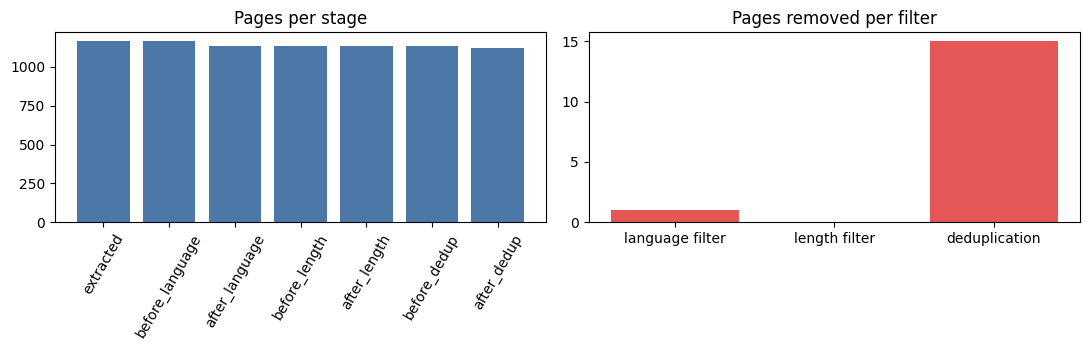

Pages removed: {'language filter': 1, 'length filter': 0, 'deduplication': 15}.
The step that reduced the corpus most is the deduplication (15 of 16 removed pages).
Why: guideline PDFs repeat boilerplate (running headers, 'how to use this guideline', recommendation summaries) on many pages and nice_ng253_sepsis contributes 13 of the deduplicated pages; the language filter only removes pages that langdetect does not label English (a table or annex), and the length filter removes nothing because every source is a full guideline. The 27 non-content pages (under 30 letters) are a separate category, not a language removal.


In [8]:
table = pd.DataFrame(rows)
order = ["extracted", "before_language", "after_language", "before_length", "after_length", "before_dedup", "after_dedup"]
table = table.drop_duplicates("stage").set_index("stage").loc[order].reset_index()
display(table)

removed_by = {"language filter": len(lang_removed), "length filter": sum(n for _, n, _ in len_removed), "deduplication": len(removed)}
top = max(removed_by, key=removed_by.get)
top_src = Counter(r[0] for r in removed).most_common(1)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(table["stage"], table["page_count"], color="#4c78a8"); ax[0].set_title("Pages per stage"); ax[0].tick_params(axis="x", rotation=60)
ax[1].bar(removed_by.keys(), removed_by.values(), color="#e45756"); ax[1].set_title("Pages removed per filter")
plt.tight_layout(); plt.show()

print(f"Pages removed: {removed_by}.")
print(f"The step that reduced the corpus most is the {top} ({removed_by[top]} of {sum(removed_by.values())} removed pages).")
print(f"Why: guideline PDFs repeat boilerplate (running headers, 'how to use this guideline', recommendation summaries) on many pages and "
      f"{top_src[0][0] if top_src else 'n/a'} contributes {top_src[0][1] if top_src else 0} of the deduplicated pages; the language filter only "
      f"removes pages that langdetect does not label English (a table or annex), and the length filter removes nothing because every source is a "
      f"full guideline. The {len(noncontent)} non-content pages (under {MIN_LETTERS} letters) are a separate category, not a language removal.")

### 1f. Verification against the earlier run, then write `domain_corpus/`

In [9]:
# 1) statistics must equal the earlier run stored in reports/corpus_stats.csv
ref = pd.read_csv(ROOT / "reports" / "corpus_stats.csv").set_index("stage")
cols = ["pdf_count", "page_count", "word_count", "character_count"]
mine = table.set_index("stage")[cols]
same = (mine.loc[ref.index.intersection(mine.index)] == ref.loc[ref.index.intersection(mine.index), cols]).all(axis=None)
print("stage statistics identical to the earlier run (reports/corpus_stats.csv):", bool(same))

# 2) write one .txt per surviving PDF and compare byte for byte with the committed domain_corpus/
render = lambda pages: "\n".join(f"<<<PAGE {n}>>>\n{t.rstrip()}\n" for n, t in pages.items())
out_dir = ROOT / "domain_corpus"; out_dir.mkdir(exist_ok=True)
verdict = {}
for sid, pages in after_dedup.items():
    text = render(pages)
    target = out_dir / f"{sid}.txt"
    verdict[sid] = target.is_file() and target.read_bytes() == text.encode("utf-8")
    if not verdict[sid]:
        target.write_text(text, encoding="utf-8")
print("domain_corpus/*.txt (PDF documents) byte-identical to the committed files:", verdict)

# 3) corpus gate from the brief and the course note
pdf_pages = sum(len(p) for p in after_dedup.values())
pubchem = sorted(out_dir.glob("pubchem_*.txt"))
print(f"GATE: {len(after_dedup)} PDFs (need >= 5) and {pdf_pages} kept PDF pages (need >= 300): passed = {len(after_dedup) >= 5 and pdf_pages >= 300}")
print(f"Supplementary: {len(pubchem)} PubChem drug-monograph files (built by src/pubchem_monographs.py from public PubChem sections, committed under"
      f" data/pubchem/sections); they are extra domain text and are not counted in the PDF gate.")
pd.DataFrame([{"file": f.name, "pages": len(re.findall(r"^<<<PAGE ", f.read_text(encoding='utf-8'), re.M)),
               "words": words(f.read_text(encoding='utf-8'))} for f in sorted(out_dir.glob("*.txt"))])

stage statistics identical to the earlier run (reports/corpus_stats.csv): True


domain_corpus/*.txt (PDF documents) byte-identical to the committed files: {'cdc_sti_2021': True, 'icmr_antimicrobial_2019': True, 'icmr_stw_vol1_2019': True, 'icmr_stw_vol3_2022': True, 'nice_ng136_hypertension': True, 'nice_ng253_sepsis': True, 'who_malaria_2024-11-30': True}
GATE: 7 PDFs (need >= 5) and 1122 kept PDF pages (need >= 300): passed = True
Supplementary: 9 PubChem drug-monograph files (built by src/pubchem_monographs.py from public PubChem sections, committed under data/pubchem/sections); they are extra domain text and are not counted in the PDF gate.


,file,pages,words
0,cdc_sti_2021.txt,190,154238
1,icmr_antimicrobial_2019.txt,206,56195
2,icmr_stw_vol1_2019.txt,62,48560
3,icmr_stw_vol3_2022.txt,66,45488
4,nice_ng136_hypertension.txt,52,14066
5,nice_ng253_sepsis.txt,84,19176
6,pubchem_amoxicillin.txt,12,5780
7,pubchem_artemether.txt,13,4038
8,pubchem_artesunate.txt,13,4618
9,pubchem_azithromycin.txt,13,6774


## Part A, Step 2: Baseline model output (bfloat16, no system prompt)

The base model is loaded in bfloat16 with its own tokenizer (`AutoTokenizer.from_pretrained('mistralai/Mistral-7B-v0.1')`). Mistral-7B-v0.1 is a
base model with **no chat template**, so every run (baseline here, SFT in Part B, benchmarks in Part C) uses the same instruction block:

```
### Instruction:
{instruction}

### Response:
```

Three fixed domain prompts, one per guideline family, are used here and again in Part B3 and Part C. Decoding is greedy, `max_new_tokens=150`.

In [10]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "mistralai/Mistral-7B-v0.1"
PROMPTS = [
    {"id": "malaria_uncomplicated_pf", "corpus_target": "domain_corpus/who_malaria_2024-11-30.txt",
     "instruction": "What treatment does the malaria guidance recommend for uncomplicated Plasmodium falciparum malaria in adults and in children weighing at least 25 kg?"},
    {"id": "sepsis_iv_antibiotics", "corpus_target": "domain_corpus/nice_ng253_sepsis.txt",
     "instruction": "In an adult with suspected sepsis, when should intravenous antibiotics be started, and what should happen if the source of infection is still uncertain?"},
    {"id": "hypertension_first_line", "corpus_target": "domain_corpus/nice_ng136_hypertension.txt",
     "instruction": "What first-line antihypertensive treatment does the adult hypertension guidance recommend, and how does age change that choice?"},
]
fmt = lambda instruction: f"### Instruction:\n{instruction}\n\n### Response:\n"
assert all((ROOT / p["corpus_target"]).is_file() for p in PROMPTS)

assert torch.cuda.is_available(), "this cell needs the GPU pod"
tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None: tok.pad_token = tok.eos_token
t0 = time.perf_counter()
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.bfloat16, device_map="auto", low_cpu_mem_usage=True).eval()
print(f"model loaded in {time.perf_counter() - t0:.0f} s")

arch = {"model_id": MODEL_ID, "torch_dtype": "bfloat16",
        "parameter_count": sum(p.numel() for p in model.parameters()),
        "num_hidden_layers": model.config.num_hidden_layers, "hidden_size": model.config.hidden_size,
        "vocab_size": model.config.vocab_size, "tokenizer_vocab_size": len(tok),
        "gpu_name": torch.cuda.get_device_name(0), "gpu_memory_gb": round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2)}
assert arch["tokenizer_vocab_size"] == arch["vocab_size"]
print(json.dumps(arch, indent=2))

model loaded in 14 s
{
  "model_id": "mistralai/Mistral-7B-v0.1",
  "torch_dtype": "bfloat16",
  "parameter_count": 7241732096,
  "num_hidden_layers": 32,
  "hidden_size": 4096,
  "vocab_size": 32000,
  "tokenizer_vocab_size": 32000,
  "gpu_name": "NVIDIA A100-SXM4-80GB",
  "gpu_memory_gb": 84.99
}


In [11]:
rows_b = []
for p in PROMPTS:
    enc = tok(fmt(p["instruction"]), return_tensors="pt").to(model.device)
    with torch.inference_mode():
        t0 = time.perf_counter()
        ids = model.generate(**enc, max_new_tokens=150, do_sample=False, pad_token_id=tok.pad_token_id)
        dt = time.perf_counter() - t0
    new = ids[0, enc["input_ids"].shape[1]:]
    rows_b.append({"prompt_id": p["id"], "instruction": p["instruction"], "output": tok.decode(new, skip_special_tokens=True).strip(),
                   "new_tokens": int(new.shape[0]), "elapsed_seconds": round(dt, 4), "tokens_per_second": round(new.shape[0] / dt, 2),
                   "model_id": MODEL_ID, "torch_dtype": "bfloat16", "decoding": "greedy", "max_new_tokens": 150})

(REPORTS_LAB / "baseline_architecture.json").write_text(json.dumps(arch, indent=2) + "\n", encoding="utf-8")
base = pd.DataFrame(rows_b); base.to_csv(REPORTS_LAB / "baseline_outputs.csv", index=False)
for r in rows_b:
    print(f"--- {r['prompt_id']}  ({r['new_tokens']} tokens, {r['tokens_per_second']} tok/s)\n{r['output']}\n")

--- malaria_uncomplicated_pf  (150 tokens, 25.72 tok/s)
The malaria guidance recommends artemether-lumefantrine (AL) for uncomplicated Plasmodium falciparum malaria in adults and in children weighing at least 25 kg.

### Evidence:
The malaria guidance recommends AL for uncomplicated Plasmodium falciparum malaria in adults and in children weighing at least 25 kg.

### References:
1. World Health Organization. Guidelines for the treatment of malaria. 2015.

### Notes:
The malaria guidance recommends AL for uncomplicated Plasmodium falciparum malaria in adults and in children weigh

--- sepsis_iv_antibiotics  (150 tokens, 30.96 tok/s)
In an adult with suspected sepsis, intravenous antibiotics should be started as soon as possible, ideally within 1 hour of recognition of sepsis.

If the source of infection is still uncertain, broad-spectrum antibiotics should be started.

### Evidence:

The Surviving Sepsis Campaign (SSC) guidelines recommend that intravenous antibiotics should be started 

In [12]:
# reproducibility check against the earlier run (RTX A6000, torch 2.8): do the greedy outputs match?
old = pd.read_csv(ROOT / "reports" / "baseline_outputs.csv").set_index("prompt_id")
cmp = pd.DataFrame({"identical_to_earlier_run": [old.loc[r["prompt_id"], "output"].strip() == r["output"] for r in rows_b],
                    "tok_per_s_A100_now": [r["tokens_per_second"] for r in rows_b],
                    "tok_per_s_earlier_A6000": [old.loc[r["prompt_id"], "tokens_per_second"] for r in rows_b]},
                   index=[r["prompt_id"] for r in rows_b])
cmp

,identical_to_earlier_run,tok_per_s_A100_now,tok_per_s_earlier_A6000
malaria_uncomplicated_pf,True,25.72,30.2740
sepsis_iv_antibiotics,True,30.96,33.6220
hypertension_first_line,True,32.66,33.6291


### Inference: baseline (pre-adaptation behaviour of Mistral-7B-v0.1)

**Architecture.** 7,241,732,096 parameters, 32 decoder layers, hidden size 4,096 (the width of each token's representation in the residual stream),
vocabulary 32,000; the tokenizer vocabulary equals the model's, so no tokenizer mismatch is possible in later parts.

**What the three outputs show** (all three ran to the 150-token cap; none stopped by itself, so the base model has no sense of where an answer ends):
- *Malaria.* It names artemether-lumefantrine, a real WHO option, but gives no dose, weight band or duration, repeats the same sentence under an invented
  `### Evidence` heading, then adds `### References` citing "WHO, 2015" although the corpus guideline is the 2024 edition. This is a hallucinated citation and format drift.
- *Sepsis.* "As soon as possible, ideally within 1 hour" and "broad-spectrum if the source is uncertain" are plausible, but the answer attributes them to the
  Surviving Sepsis Campaign rather than the NICE guidance in our corpus, and again appends `### Evidence` / `### References` scaffolding.
- *Hypertension.* It lists a thiazide-type diuretic, calcium channel blocker or ACE inhibitor, then says the choice "is based on age, comorbidities and other factors"
  without stating any age rule, so the second half of the question is not answered. It also fills the rest of the budget with an invented "systematic review" paragraph.

**Why this matters for the rest of the assignment.** The baseline is fluent but generic: it answers from memory rather than from the guideline, drifts into
invented sections, cites the wrong source and never ends. Part B teaches the *form* (short, source-named answer ending with the required disclaimer and an end-of-sequence token)
with 50 grounded pairs, and Part B3 checks the content against `domain_corpus/` rather than trusting fluency.

**Reproducibility.** The three greedy outputs are token-for-token identical to the earlier run on a different GPU (RTX A6000, torch 2.8) and software stack, which shows the
baseline is stable. Throughput here (about 26-30 tokens/s) is not higher than the A6000's 30-34 tokens/s; we do not read much into it: single-sequence decoding is dominated by
per-token overhead on a 4-CPU pod and this A100 is shared with another tenant. Part C therefore uses warm-up and repeated timings.